In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt

In [356]:
import string
string.ascii_letters

'abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ'

In [357]:
import random
random.seed(1234)
random.choice(string.ascii_letters).lower()

'x'

In [ ]:
from pathlib import Path

DATA_DIR = Path.cwd()

def split_repositories(path, randomize=True):
    """Return a mapping of repo name -> number of rows in each .ab.csv file."""
    repo_lengths = {}
    path = Path(path)
    for file_path in path.glob("*.ab.csv"):
        file_name = file_path.name.split('.')[0]
        if randomize:
            file_name = f"{random.choice(string.ascii_letters).lower()}_{file_name}"
        try:
            df = pd.read_csv(file_path, sep='\t')
        except Exception as exc:
            print(f"Failed to read {file_path}: {exc}")
            continue
        repo_lengths[file_name] = len(df)

    return repo_lengths

In [ ]:
parent_folder = DATA_DIR
wg_length_dict_randomize = split_repositories(parent_folder, randomize=True)
wg_length_dict = split_repositories(parent_folder, randomize=False)

In [361]:
wg_length_dict

{'draft-ice-pac': 39,
 'rtcweb-transport': 87,
 'eap-aka-pfs': 28,
 'draft-ietf-jsonpath-base': 1272,
 'dtls13-spec': 616,
 'draft-webtransport-http2': 467,
 'gnap-resource-servers': 173,
 'draft-ietf-git-github-wg-configuration': 28,
 'deprecation-header': 67,
 'anima-bootstrap': 115,
 'quic-v2': 116,
 'draft-ietf-tls-grease': 5,
 'trickle': 6,
 'draft-ietf-webtrans-http3': 242,
 'ietf-ccamp-layer0-types-ext-RFC9093-bis': 5,
 'mls-protocol': 4084,
 'draft-ietf-dnsop-terminology-bis': 107,
 'draft-ietf-rats-uccs': 17,
 'smime': 302,
 'ops-drafts': 1792,
 'draft-ietf-detnet-dp-sol-ip': 267,
 'draft-ietf-tls-ticketrequest': 114,
 'vulnerability-scenario': 19,
 'draft-irtf-nwcrg-coding-and-congestion-in-transport': 569,
 'ace-key-groupcomm-oscore': 1117,
 'quicwg-base-drafts': 13095,
 'using-github': 291,
 'new-block': 410,
 'coap-pubsub': 166,
 'draft-ietf-sacm-requirements': 53,
 'draft-ietf-sacm-coswid': 1091,
 't2trg-iot-edge-computing': 139,
 'mud-reporter': 14,
 'oscore-edhoc': 114,

In [362]:
wg_length_dict['rpl-observations']

1

In [363]:
wg_length_df = pd.DataFrame(wg_length_dict_randomize.items(), columns=['wg', 'length'])
wg_length_df

,wg,length
0,c_draft-ice-pac,39
1,h_rtcweb-transport,87
2,a_eap-aka-pfs,28
3,f_draft-ietf-jsonpath-base,1272
4,z_dtls13-spec,616
...,...,...
161,g_draft-ietf-taps-transport-security,656
162,f_draft-ietf-add-svcb-dns,49
163,y_draft-ietf-dmarc-dmarcbis,148
164,s_security,80


In [364]:
wg_length_df = wg_length_df.reindex(wg_length_df.index.repeat(wg_length_df.length))
wg_length_df

,wg,length
0,c_draft-ice-pac,39
0,c_draft-ice-pac,39
0,c_draft-ice-pac,39
0,c_draft-ice-pac,39
0,c_draft-ice-pac,39
...,...,...
165,u_tls-flags,43
165,u_tls-flags,43
165,u_tls-flags,43
165,u_tls-flags,43


In [365]:
codes = wg_length_df.wg.astype("category").cat.codes    
codes

0       14
0       14
0       14
0       14
0       14
      ... 
165    137
165    137
165    137
165    137
165    137
Length: 89562, dtype: int16

In [366]:
nbins = 5
wg_length_df["bin"] = pd.qcut(codes, nbins, labels=False)
wg_length_df.groupby("wg").bin.value_counts()

wg                                            bin
a_brski-cloud                                 0       78
a_draft-ietf-sacm-requirements                0       53
a_eap-aka-pfs                                 0       28
a_quicwg-datagram                             0      120
a_yang                                        0       49
                                                    ... 
z_draft-irtf-nwcrg-network-coding-satellites  4      144
z_dtls13-spec                                 4      616
z_multipath                                   4      807
z_rfc8447bis                                  4      102
z_snip                                        4        2
Name: bin, Length: 166, dtype: int64

In [ ]:
print(len(wg_length_df[wg_length_df['bin'] == 0]))
print(len(wg_length_df[wg_length_df['bin'] == 1]))
print(len(wg_length_df[wg_length_df['bin'] == 2]))
print(len(wg_length_df[wg_length_df['bin'] == 3]))
print(len(wg_length_df[wg_length_df['bin'] == 4]))

18363
23158
12360
18161
17520


In [316]:
wg_length_df[wg_length_df['bin'] == 0].head(40)

,wg,length,bin
0,c_draft-ice-pac,39,0
0,c_draft-ice-pac,39,0
0,c_draft-ice-pac,39,0
0,c_draft-ice-pac,39,0
0,c_draft-ice-pac,39,0
0,c_draft-ice-pac,39,0
0,c_draft-ice-pac,39,0
0,c_draft-ice-pac,39,0
0,c_draft-ice-pac,39,0
0,c_draft-ice-pac,39,0


In [335]:
wgs = {}
for b in range(5):
    wgs[b] = wg_length_df[wg_length_df['bin'] == b]['wg'].unique().tolist()

In [336]:
wgs

{0: ['c_draft-ice-pac',
  'a_eap-aka-pfs',
  'c_gnap-resource-servers',
  'b_ietf-ccamp-layer0-types-ext-RFC9093-bis',
  'b_mls-protocol',
  'b_draft-ietf-rats-uccs',
  'e_draft-ietf-tls-ticketrequest',
  'd_draft-irtf-nwcrg-coding-and-congestion-in-transport',
  'a_draft-ietf-sacm-requirements',
  'e_oscore-edhoc',
  'd_draft-ietf-add-requirements',
  'c_ietf-wg-privacypass-base-drafts',
  'e_https-notif',
  'd_cose-spec',
  'b_autonomic-control-plane',
  'e_mediatypes',
  'a_yang',
  'e_lxnm',
  'd_draft-ietf-ccamp-optical-impairment-topology-yang',
  'e_groupcomm-bis',
  'e_ip-handling',
  'b_mqtt-tls-profile',
  'd_draft-ietf-tls-external-psk-importer',
  'c_draft-ietf-tls-iana-registry-updates',
  'a_quicwg-datagram',
  'c_senml-data-ct',
  'd_resource-directory',
  'c_X509',
  'd_draft-ietf-masque-connect-ip',
  'e_ratelimit-headers',
  'c_acme',
  'e_draft-ietf-add-ddr',
  'c_linkset',
  'c_senml-etch',
  'a_brski-cloud',
  'b_rfc7807bis',
  'c_fec',
  'd_ace-key-groupcomm',
  '

In [337]:
for b in range(5):
    wgs[b] = [item.split('_')[1] for item in wgs[b]]
    print(len(wgs[b]))

39
12
24
40
51


In [338]:
wgs

{0: ['draft-ice-pac',
  'eap-aka-pfs',
  'gnap-resource-servers',
  'ietf-ccamp-layer0-types-ext-RFC9093-bis',
  'mls-protocol',
  'draft-ietf-rats-uccs',
  'draft-ietf-tls-ticketrequest',
  'draft-irtf-nwcrg-coding-and-congestion-in-transport',
  'draft-ietf-sacm-requirements',
  'oscore-edhoc',
  'draft-ietf-add-requirements',
  'ietf-wg-privacypass-base-drafts',
  'https-notif',
  'cose-spec',
  'autonomic-control-plane',
  'mediatypes',
  'yang',
  'lxnm',
  'draft-ietf-ccamp-optical-impairment-topology-yang',
  'groupcomm-bis',
  'ip-handling',
  'mqtt-tls-profile',
  'draft-ietf-tls-external-psk-importer',
  'draft-ietf-tls-iana-registry-updates',
  'quicwg-datagram',
  'senml-data-ct',
  'resource-directory',
  'X509',
  'draft-ietf-masque-connect-ip',
  'ratelimit-headers',
  'acme',
  'draft-ietf-add-ddr',
  'linkset',
  'senml-etch',
  'brski-cloud',
  'rfc7807bis',
  'fec',
  'ace-key-groupcomm',
  'dnssec-chain-extension'],
 1: ['draft-ietf-jsonpath-base',
  'anima-bootstra

In [ ]:
overview_update = pd.read_csv(parent_folder / "overview-update.tsv", sep="\t")
overview_update

,repo,file_name,file_volume,file_type,total_volume,num_of_drafts,main_file_type,URL,Single,num_of_versions
0,draft-ietf-add-split-horizon-authority,draft-ietf-add-split-horizon-authority.xml,{'draft-ietf-add-split-horizon-authority.xml':...,{'xml': 24},24,1,xml,NaN,Y,1
1,draft-ietf-add-svcb-dns,draft-schwartz-svcb-dns.md\ndraft-ietf-add-svc...,"{'draft-schwartz-svcb-dns.md': 8, 'draft-ietf-...",{'md': 28},28,2,md,draft-schwartz-svcb-dns: draft-ietf-add-svcb-d...,Y,1
2,draft-ietf-add-requirements,draft-add-requirements.md,{'draft-add-requirements.md': 10},{'md': 10},10,1,md,NaN,Y,1
3,constrained-voucher,constrained-voucher.mkd\nconstrained-voucher.xml,"{'constrained-voucher.mkd': 242, 'constrained-...","{'mkd': 242, 'xml': 16}",258,2,mkd,NaN,Y,1
4,anima-brski-prm,draft-ietf-anima-brski-prm.md,{'draft-ietf-anima-brski-prm.md': 16},{'md': 16},16,1,md,NaN,Y,1
...,...,...,...,...,...,...,...,...,...,...
165,bundled-responses,draft-ietf-wpack-bundled-responses.md,{'draft-ietf-wpack-bundled-responses.md': 14},{'md': 14},14,1,md,NaN,Y,1
166,draft-ietf-add-ddr,draft-ietf-add-ddr.md,{'draft-ietf-add-ddr.md': 106},{'md': 106},106,1,md,NaN,Y,1
167,draft-ietf-emu-eap-tls13,draft-ietf-emu-eap-tls13.xml,{'draft-ietf-emu-eap-tls13.xml': 66},{'xml': 66},66,1,xml,NaN,Y,1
168,draft-irtf-nwcrg-coding-and-congestion-in-tran...,draft-irtf-nwcrg-coding-and-congestion-04.xml\...,{'draft-irtf-nwcrg-coding-and-congestion-04.xm...,{'xml': 50},50,7,xml,draft-irtf-nwcrg-coding-and-congestion-04: rfc...,Y,1


In [373]:
for b in range(5):
    sum_num_of_versions, sum_num_of_total_volume = 0, 0
    for wg in wgs[b]:
        sum_num_of_versions += int(overview_update[overview_update['repo'] == wg]['num_of_versions'])
        if int(overview_update[overview_update['repo'] == wg]['total_volume']) %2 !=0:
            print(wg)
        sum_num_of_total_volume += int(overview_update[overview_update['repo'] == wg]['total_volume'])
    print(sum_num_of_versions, sum_num_of_total_volume)

46 4106
24 5648
31 2868
50 4238
58 5292


In [339]:
import pickle

with open("repo.statistics", "wb") as f:
    pickle.dump(wgs, f)

In [340]:
repos_5fold = {}

with open("repo.statistics", "rb") as f:
    repos_5fold = pickle.load(f)
    
print(repos_5fold)

{0: ['draft-ice-pac', 'eap-aka-pfs', 'gnap-resource-servers', 'ietf-ccamp-layer0-types-ext-RFC9093-bis', 'mls-protocol', 'draft-ietf-rats-uccs', 'draft-ietf-tls-ticketrequest', 'draft-irtf-nwcrg-coding-and-congestion-in-transport', 'draft-ietf-sacm-requirements', 'oscore-edhoc', 'draft-ietf-add-requirements', 'ietf-wg-privacypass-base-drafts', 'https-notif', 'cose-spec', 'autonomic-control-plane', 'mediatypes', 'yang', 'lxnm', 'draft-ietf-ccamp-optical-impairment-topology-yang', 'groupcomm-bis', 'ip-handling', 'mqtt-tls-profile', 'draft-ietf-tls-external-psk-importer', 'draft-ietf-tls-iana-registry-updates', 'quicwg-datagram', 'senml-data-ct', 'resource-directory', 'X509', 'draft-ietf-masque-connect-ip', 'ratelimit-headers', 'acme', 'draft-ietf-add-ddr', 'linkset', 'senml-etch', 'brski-cloud', 'rfc7807bis', 'fec', 'ace-key-groupcomm', 'dnssec-chain-extension'], 1: ['draft-ietf-jsonpath-base', 'anima-bootstrap', 'quicwg-base-drafts', 'sniencryption', 'countersign', 'rfc5245bis', 'mls-ar

In [341]:
lst = list(repos_5fold.values())

In [342]:
lst[0]

['draft-ice-pac',
 'eap-aka-pfs',
 'gnap-resource-servers',
 'ietf-ccamp-layer0-types-ext-RFC9093-bis',
 'mls-protocol',
 'draft-ietf-rats-uccs',
 'draft-ietf-tls-ticketrequest',
 'draft-irtf-nwcrg-coding-and-congestion-in-transport',
 'draft-ietf-sacm-requirements',
 'oscore-edhoc',
 'draft-ietf-add-requirements',
 'ietf-wg-privacypass-base-drafts',
 'https-notif',
 'cose-spec',
 'autonomic-control-plane',
 'mediatypes',
 'yang',
 'lxnm',
 'draft-ietf-ccamp-optical-impairment-topology-yang',
 'groupcomm-bis',
 'ip-handling',
 'mqtt-tls-profile',
 'draft-ietf-tls-external-psk-importer',
 'draft-ietf-tls-iana-registry-updates',
 'quicwg-datagram',
 'senml-data-ct',
 'resource-directory',
 'X509',
 'draft-ietf-masque-connect-ip',
 'ratelimit-headers',
 'acme',
 'draft-ietf-add-ddr',
 'linkset',
 'senml-etch',
 'brski-cloud',
 'rfc7807bis',
 'fec',
 'ace-key-groupcomm',
 'dnssec-chain-extension']

### cross repositories

In [ ]:
from random import sample
import numpy as np

def func(wg, wgs, wg_length_dict, K, data_dir=DATA_DIR):
    """Create positive/negative TSVs for a repo using cross-repo negatives."""
    data_dir = Path(data_dir)
    N = wg_length_dict[wg]
    wg_df = pd.read_csv(data_dir / f"{wg}.ab.csv", sep='\t')
    wg_paras = wg_df['paragraph']
    pos_instances = pd.concat(
        [wg_df['paragraph'], wg_df['commentary'], pd.DataFrame(np.repeat(1, N)), wg_df['draft']],
        axis=1, ignore_index=True
    )
    pos_instances.rename(columns={0: 'paragraph', 1: 'commentary', 2: 'label', 3: 'draft'}, inplace=True)
    pos_instances.to_csv(data_dir / f"{wg}.pos.tsv", sep='\t', encoding='utf-8', index=False)
    
    other_wgs = [g for g in wgs if g != wg]
    other_comments = []
    for owg in other_wgs:
        df = pd.read_csv(data_dir / f"{owg}.ab.csv", sep='\t')
        other_comments.append(df['commentary'])
    all_other_comments = pd.concat(other_comments, ignore_index=True)
    
    K_neg_indices = np.random.choice(all_other_comments.shape[0], size=K * N, replace=True)
    K_neg_instances = all_other_comments.iloc[K_neg_indices].reset_index(drop=True)
    K_wg_paras = wg_paras.reindex(wg_paras.index.repeat(K)).reset_index(drop=True)
    neg_instances = pd.concat([K_wg_paras, K_neg_instances], axis=1, ignore_index=True)
    neg_instances = pd.concat([neg_instances, pd.DataFrame(np.repeat(0, K * N))], axis=1, ignore_index=True)
    neg_instances.rename(columns={0: 'paragraph', 1: 'commentary', 2: 'label', 3: 'draft'}, inplace=True)
    neg_instances.to_csv(data_dir / f"{wg}.neg.tsv", sep='\t', encoding='utf-8', index=False)

In [115]:
# func('7710bis', lst[4], wg_length_dict, 1)

In [116]:
import time
import numpy as np

start = time.time()

for wgs in lst:
    for wg in wgs:
        func(wg, wgs, wg_length_dict, 1)

end = time.time()
print(end - start)

79.8474440574646


In [444]:
import itertools

test = lst[0]
valid = lst[1]
train = lst[2:5]
train = list(itertools.chain.from_iterable(train))

In [396]:
# train.remove('mediatypes')

In [ ]:
pos_all = pd.DataFrame()
neg_all = pd.DataFrame()

for draft in test:
    pos = pd.read_csv(parent_folder / f"{draft}.pos.tsv", sep='\t').reset_index(drop=True)
    pos_all = pd.concat([pos_all, pos], ignore_index=True).reset_index(drop=True)
    neg = pd.read_csv(parent_folder / f"{draft}.neg.tsv", sep='\t')
    neg_all = pd.concat([neg_all, neg], ignore_index=True).reset_index(drop=True)

both_all = pd.concat([pos_all, neg_all])
both_all.shape

(41616, 3)

In [120]:
both_all.sample(frac=1).reset_index(drop=True)

,paragraph,commentary,label
0,construct a url by populating the url template...,Merging based on NAME review,1
1,"""nonce"": a unique sequence of bytes used to en...","Fixes NUMBER As discussed in NUMBER, this PR m...",0
2,the collect protocol is an iterative procedure...,Squashed.\nLGTM modulo one nit,1
3,if the application has supplied external authe...,Changes to key schedule and corresponding dire...,0
4,this section details use-cases where coding te...,A first sentence says quasi-error-free is usua...,1
...,...,...,...
41611,"to verify a token, a verifier creates a voprf ...",Closes NUMBER Closes NUMBER\nHexadecimal const...,1
41612,"esp packets are sent directly over ip, except ...","There are more changes I want to make, but man...",1
41613,'coding rate' (output control plane for the fe...,The RFC Editor has completed their editing pas...,0
41614,"however, the cose_recipient structure can cont...",Remove RSA algorithms to be placed in the seco...,0


In [ ]:
def gen(group, name, data_dir=DATA_DIR):
    """Generate a shuffled TSV from a group of repos."""
    data_dir = Path(data_dir)
    pos_frames = []
    neg_frames = []

    for draft in group:
        pos = pd.read_csv(data_dir / f"{draft}.pos.tsv", sep='\t').reset_index(drop=True)
        pos_frames.append(pos)
        neg = pd.read_csv(data_dir / f"{draft}.neg.tsv", sep='\t')
        neg_frames.append(neg)

    both_all = pd.concat([*pos_frames, *neg_frames], ignore_index=True)
    both_all.sample(frac=1).reset_index(drop=True) \
        .to_csv(data_dir / f"{name}.1.tsv", sep='\t', encoding='utf-8', index=False)

In [122]:
gen(train, "train")

In [123]:
gen(valid, "valid")

In [124]:
gen(test, "test")

### end of cross repositories

In [ ]:
# my old way of generate negative instances within the same repositories
import numpy as np

def generate_negative_instances(wg, K=1, data_dir=DATA_DIR):
    """Generate positive/negative instances within the same repository."""
    data_dir = Path(data_dir)
    pos_instances = []
    neg_instances = []
    df = pd.read_csv(data_dir / f"{wg}.ab.csv", sep='\t')
    prs = df['pr']
    grouped = df.groupby('paragraph')

    for para, group in grouped:
        pos_prs = group['pr'].unique().tolist()
        pos_num = len(pos_prs)
        neg_prs = [pr for pr in prs.unique() if pr not in pos_prs]
        if pos_num:
            pos_rows = group.drop_duplicates(subset=['pr'])[['pr', 'paragraph', 'commentary', 'draft']]
            for _, row in pos_rows.iterrows():
                pos_instances.append([row['pr'], row['paragraph'], row['commentary'], 1, row['draft'], wg])
        if neg_prs:
            neg_prs = np.random.choice(neg_prs, size=K * pos_num, replace=True)
            for neg in neg_prs:
                neg_case = df.loc[df["pr"] == neg].iloc[0]
                neg_instances.append([neg, para, neg_case["commentary"], 0, neg_case["draft"], wg])
    
    if pos_instances:
        df_pos = pd.DataFrame(pos_instances, columns=['pr', 'paragraph', 'commentary', 'label', 'draft', 'wg'])
        df_pos.drop_duplicates(subset=['paragraph', 'pr'], inplace=True, keep='first')
        df_pos.to_csv(data_dir / f"{wg}.pos.tsv", sep='\t', encoding='utf-8', index=False)
    if neg_instances:
        df_neg = pd.DataFrame(neg_instances, columns=['pr', 'paragraph', 'commentary', 'label', 'draft', 'wg'])
        df_neg.drop_duplicates(subset=['paragraph', 'pr'], inplace=True, keep='first')
        df_neg.to_csv(data_dir / f"{wg}.neg.tsv", sep='\t', encoding='utf-8', index=False)

In [327]:
import itertools

valid = lst[0]
train = lst[1:]

train = list(itertools.chain.from_iterable(train))

In [328]:
import time
import numpy as np

start = time.time()

for wgs in lst:
    for wg in wgs:
        generate_negative_instances(wg)

end = time.time()
print(end - start)

64.85042309761047


In [ ]:
def gen(group, name, data_dir=DATA_DIR):
    """Generate a shuffled TSV from a group of repos (skip missing files)."""
    data_dir = Path(data_dir)
    pos_frames = []
    neg_frames = []

    for draft in group:
        pos_file = data_dir / f"{draft}.pos.tsv"
        neg_file = data_dir / f"{draft}.neg.tsv"
        if pos_file.exists():
            pos_frames.append(pd.read_csv(pos_file, sep='\t').reset_index(drop=True))
        if neg_file.exists():
            neg_frames.append(pd.read_csv(neg_file, sep='\t').reset_index(drop=True))

    if not pos_frames and not neg_frames:
        return
    both_all = pd.concat([*pos_frames, *neg_frames], ignore_index=True)
    both_all.sample(frac=1).reset_index(drop=True) \
        .to_csv(data_dir / f"{name}.1.tsv", sep='\t', encoding='utf-8', index=False)

In [330]:
gen(train, "train")

In [331]:
gen(valid, "valid")

### check consistency

In [ ]:
for file in os.listdir(parent_folder):
    file_path = parent_folder / file
    if file_path.suffixes == ['.ab', '.csv'] or str(file_path).endswith('.ab.csv'):
        file_name = file_path.stem.split('.')[0]
        ab_ins = len(pd.read_csv(parent_folder / f"{file_name}.ab.csv", sep="\t"))
        pos_ins = len(pd.read_csv(parent_folder / f"{file_name}.pos.tsv", sep="\t"))
        neg_file = parent_folder / f"{file_name}.neg.tsv"
        neg_ins = len(pd.read_csv(neg_file, sep="\t")) if neg_file.exists() else 0
        if pos_ins * 3 != neg_ins:
            print(file_name, ab_ins, pos_ins, neg_ins)

draft-ice-pac 39 39 93
rtcweb-transport 89 89 239
eap-aka-pfs 13 13 27
draft-ietf-jsonpath-base 1455 1455 4300
dtls13-spec 621 621 1823
draft-webtransport-http2 526 526 1509
gnap-resource-servers 186 186 494
draft-ietf-git-github-wg-configuration 28 28 59
deprecation-header 87 87 170
anima-bootstrap 124 124 325
quic-v2 131 131 365
draft-ietf-tls-grease 9 9 14
trickle 6 6 6
draft-ietf-webtrans-http3 280 280 794
ietf-ccamp-layer0-types-ext-RFC9093-bis 8 8 8
mls-protocol 5140 5140 15266
draft-ietf-dnsop-terminology-bis 304 304 864
draft-ietf-rats-uccs 19 19 35
smime 288 288 771
ops-drafts 1799 1799 5329
draft-ietf-detnet-dp-sol-ip 290 290 764
draft-ietf-tls-ticketrequest 123 123 294
vulnerability-scenario 19 19 19
draft-irtf-nwcrg-coding-and-congestion-in-transport 595 595 1609
ace-key-groupcomm-oscore 1132 1132 2573
quicwg-base-drafts 12961 12961 38684
using-github 291 291 806
new-block 413 413 1110
coap-pubsub 187 187 473
draft-ietf-sacm-requirements 50 50 103
draft-ietf-sacm-coswid 119

### same operation on test set

In [ ]:
def generate_negative_instances_testset(parent_folder, wg, K=1):
    """Generate negative instances for test-set TSVs."""
    parent_folder = Path(parent_folder)
    neg_instances = []
    df = pd.read_csv(parent_folder / f"{wg}.pos.tsv", sep='\t')
    urls = df['url']
    grouped = df.groupby('paragraph')

    for para, group in grouped:
        pos_urls = group['url'].unique().tolist()
        pos_num = len(pos_urls)
        neg_urls = [url for url in urls.unique() if url not in pos_urls]
        if neg_urls and pos_num:
            neg_urls = np.random.choice(neg_urls, size=K * pos_num, replace=True)
            for neg in neg_urls:
                neg_case = df.loc[df["url"] == neg].iloc[0]
                neg_instances.append([neg, para, neg_case["commentary"], 0])
    
    if neg_instances:
        df_neg = pd.DataFrame(neg_instances, columns=['url', 'paragraph', 'commentary', 'label'])
        df_neg.drop_duplicates(subset=['paragraph', 'url'], inplace=True, keep='first')
        df_neg.to_csv(parent_folder / f"{wg}.neg.tsv", sep='\t', encoding='utf-8', index=False)

In [ ]:
generate_negative_instances_testset("./testset/7657/", "rfc7657", K=1)

In [ ]:
generate_negative_instances_testset("./testset/8335/", "rfc8335-draft-bonica-intarea-eping", K=1)

In [ ]:
generate_negative_instances_testset("./testset/8335/", "rfc8335-draft-ietf-intarea-probe", K=1)

In [ ]:
rfc7657_pos = pd.read_csv("./testset/7657/rfc7657.pos.tsv", sep="\t")
rfc7657_neg = pd.read_csv("./testset/7657/rfc7657.neg.tsv", sep="\t")

rfc7657 = pd.concat([rfc7657_pos, rfc7657_neg], axis=0)
rfc7657.to_csv("./testset/7657/rfc7657.tsv", sep="\t", index=False)

In [ ]:
rfc8335_1_pos = pd.read_csv("./testset/8335/rfc8335-draft-bonica-intarea-eping.pos.tsv", sep="\t")

rfc8335_2_pos = pd.read_csv("./testset/8335/rfc8335-draft-ietf-intarea-probe.pos.tsv", sep="\t")

In [ ]:
rfc8335_pos = pd.concat([rfc8335_1_pos, rfc8335_2_pos], axis=0)
rfc8335_pos.to_csv("./testset/8335/rfc8335.pos.tsv", sep="\t", index=False)

In [ ]:
rfc8335_1_neg = pd.read_csv("./testset/8335/rfc8335-draft-bonica-intarea-eping.neg.tsv", sep="\t")

rfc8335_2_neg = pd.read_csv("./testset/8335/rfc8335-draft-ietf-intarea-probe.neg.tsv", sep="\t")


In [ ]:
rfc8335_neg = pd.concat([rfc8335_1_neg, rfc8335_2_neg], axis=0)
rfc8335_neg.to_csv("./testset/8335/rfc8335.neg.tsv", sep="\t", index=False)

In [ ]:
rfc8335 = pd.concat([rfc8335_pos, rfc8335_neg], axis=0)
rfc8335.to_csv("./testset/8335/rfc8335.tsv", sep="\t", index=False)

### end of operation on test set

### analysis per git repository

In [ ]:
# gp3 = pd.read_csv("group/group.3.csv", sep="\t")
gp3 = pd.read_csv("AB/short/group.0.csv", sep="\t")
gp3_= pd.read_csv("AplusB/short/group.2.csv", sep="\t")

In [1732]:
gp3_1 = gp3#[gp3["pred"] >= 0.5] # gp3_1 = gp3[gp3["label"] == 1]
gp3_1_ = gp3_#[gp3_["pred"] >= 0.5]

In [1733]:
gp3_1.sort_values(['pred'], ascending=False)
gp3_1_.sort_values(['pred'], ascending=False)

,Unnamed: 0,pred,label,draft,wg
28296,28296,0.994676,1.0,draft-ietf-cose-msg,cose-spec
6558,6558,0.993997,1.0,draft-ietf-ace-oauth-authz,ace-oauth
33290,33290,0.993982,1.0,draft-ietf-ace-oauth-authz,ace-oauth
17331,17331,0.993356,0.0,draft-ietf-httpapi-ratelimit-headers,ratelimit-headers
4071,4071,0.993316,1.0,draft-ietf-quic-datagram,quicwg-datagram
...,...,...,...,...,...
4645,4645,0.001027,0.0,draft-ietf-httpapi-ratelimit-headers,ratelimit-headers
12806,12806,0.000993,0.0,draft-ietf-mls-protocol,mls-protocol
23087,23087,0.000964,0.0,draft-ietf-quic-datagram,quicwg-datagram
34120,34120,0.000929,0.0,draft-ietf-mls-protocol,mls-protocol


In [ ]:
sorted_df = gp3_1.groupby('draft').apply(lambda x: x.sort_values('pred', ascending=False)).reset_index(drop=True)

sorted_df_= gp3_1_.groupby('draft').apply(lambda x: x.sort_values('pred', ascending=False)).reset_index(drop=True)

In [ ]:
overview = pd.read_csv(parent_folder / "overview-update.tsv", sep="\t")
overview

,repo,file_name,file_volume,file_type,total_volume,num_of_drafts,main_file_type,URL,Single,num_of_versions
0,draft-ietf-add-split-horizon-authority,draft-ietf-add-split-horizon-authority.xml,{'draft-ietf-add-split-horizon-authority.xml':...,{'xml': 24},24,1,xml,NaN,Y,1
1,draft-ietf-add-svcb-dns,draft-schwartz-svcb-dns.md\ndraft-ietf-add-svc...,"{'draft-schwartz-svcb-dns.md': 8, 'draft-ietf-...",{'md': 28},28,2,md,draft-schwartz-svcb-dns: draft-ietf-add-svcb-d...,Y,1
2,draft-ietf-add-requirements,draft-add-requirements.md,{'draft-add-requirements.md': 10},{'md': 10},10,1,md,NaN,Y,1
3,constrained-voucher,constrained-voucher.mkd\nconstrained-voucher.xml,"{'constrained-voucher.mkd': 242, 'constrained-...","{'mkd': 242, 'xml': 16}",258,2,mkd,NaN,Y,1
4,anima-brski-prm,draft-ietf-anima-brski-prm.md,{'draft-ietf-anima-brski-prm.md': 16},{'md': 16},16,1,md,NaN,Y,1
...,...,...,...,...,...,...,...,...,...,...
165,bundled-responses,draft-ietf-wpack-bundled-responses.md,{'draft-ietf-wpack-bundled-responses.md': 14},{'md': 14},14,1,md,NaN,Y,1
166,draft-ietf-add-ddr,draft-ietf-add-ddr.md,{'draft-ietf-add-ddr.md': 106},{'md': 106},106,1,md,NaN,Y,1
167,draft-ietf-emu-eap-tls13,draft-ietf-emu-eap-tls13.xml,{'draft-ietf-emu-eap-tls13.xml': 66},{'xml': 66},66,1,xml,NaN,Y,1
168,draft-irtf-nwcrg-coding-and-congestion-in-tran...,draft-irtf-nwcrg-coding-and-congestion-04.xml\...,{'draft-irtf-nwcrg-coding-and-congestion-04.xm...,{'xml': 50},50,7,xml,draft-irtf-nwcrg-coding-and-congestion-04: rfc...,Y,1


In [1736]:
multi_draft_repos = overview[overview['Single'] == "N"]["repo"].tolist()
multi_draft_repos

['X509',
 'cose-rfc8152bis',
 'data-plane-drafts',
 'using-github',
 'mediatypes',
 'edhoc',
 'smime',
 'oblivious-http',
 'lxnm',
 'ietf-wg-privacypass-base-drafts',
 'perc-wg',
 'qlog',
 'ops-drafts',
 'load-balancers',
 'quicwg-base-drafts',
 'tls13-spec',
 'api-drafts',
 'webpush-vapid',
 'webpush-protocol',
 'draft-ietf-webtrans-http3']

In [ ]:
import ast

with open(parent_folder/"draft_dictionary.txt", "r") as data:
    dictionary = ast.literal_eval(data.read())

In [1738]:
dictionary

{'draft-schwartz-svcb-dns': 'draft-ietf-add-svcb-dns',
 'draft-ietf-add-svcb-dns': 'draft-ietf-add-svcb-dns',
 'draft-ietf-anima-brski-async-enroll': 'draft-ietf-anima-brski-ae',
 'draft-ietf-anima-brski-ae': 'draft-ietf-anima-brski-ae',
 'draft-ietf-acme-acme': 'rfc8555',
 'draft-ietf-acme-acme.clean': 'rfc8555',
 'draft-ietf-acme': 'rfc8555',
 'rfc8555.src-clean': 'fc8555',
 'rfc8555.edited': 'rfc8555',
 'draft-ietf-ace-dtls-authorize': 'rfc9202',
 'draft-ietf-ccamp-layer0-types-ext': 'draft-ietf-ccamp-rfc9093-bis',
 'draft-ietf-ccamp-rfc9093-bis': 'draft-ietf-ccamp-rfc9093-bis',
 'draft-ietf-core-pubsub': 'draft-ietf-core-pubsub',
 'draft-ietf-core-coap-pubsub': 'draft-ietf-core-coap-pubsub',
 'draft-ietf-core-resource-directory': 'rfc9176',
 'draft-ietf-core-echo-request-tag': 'rfc9175',
 'draft-amsuess-core-repeat-request-tag': 'rfc9175',
 'draft-ekwk-capport-rfc7710bis': 'rfc8910',
 'draft-ietf-capport-rfc7710bis': 'rfc8910',
 'draft-ietf-cose-hash-algs': 'rfc9054',
 'draft-ietf-

In [1739]:
draft_rename = []
for draft in gp3_1['draft']:
    if draft in dictionary:
        draft_rename.append(dictionary[draft])
    else:
        draft_rename.append(draft)
        
draft_rename_ = []
for draft in gp3_1_['draft']:
    if draft in dictionary:
        draft_rename_.append(dictionary[draft])
    else:
        draft_rename_.append(draft)

In [1740]:
gp3_1['draft_rename'] = draft_rename
gp3_1_['draft_rename'] = draft_rename_

In [1741]:
sorted_df = gp3_1.groupby('draft_rename').apply(lambda x: x.sort_values('pred', ascending=False)).reset_index(drop=True)

sorted_df

,Unnamed: 0,pred,label,draft,wg,draft_rename
0,11975,0.697431,0.0,draft-add-requirements,draft-ietf-add-requirements,draft-add-requirements
1,20204,0.691814,0.0,draft-add-requirements,draft-ietf-add-requirements,draft-add-requirements
2,896,0.683314,0.0,draft-add-requirements,draft-ietf-add-requirements,draft-add-requirements
3,15004,0.683015,0.0,draft-add-requirements,draft-ietf-add-requirements,draft-add-requirements
4,19430,0.681684,0.0,draft-add-requirements,draft-ietf-add-requirements,draft-add-requirements
...,...,...,...,...,...,...
34707,2595,0.180894,0.0,draft-ietf-cose-x509,X509,rfc9360
34708,11375,0.165488,0.0,draft-ietf-cose-x509,X509,rfc9360
34709,33527,0.162723,0.0,draft-ietf-cose-x509,X509,rfc9360
34710,10934,0.157987,0.0,draft-ietf-cose-x509,X509,rfc9360


In [1742]:
sorted_df_ = gp3_1_.groupby('draft_rename').apply(lambda x: x.sort_values('pred', ascending=False)).reset_index(drop=True)

sorted_df_

,Unnamed: 0,pred,label,draft,wg,draft_rename
0,25386,0.971298,1.0,draft-add-requirements,draft-ietf-add-requirements,draft-add-requirements
1,12748,0.966654,1.0,draft-add-requirements,draft-ietf-add-requirements,draft-add-requirements
2,11224,0.964906,1.0,draft-add-requirements,draft-ietf-add-requirements,draft-add-requirements
3,30937,0.961298,1.0,draft-add-requirements,draft-ietf-add-requirements,draft-add-requirements
4,30870,0.956659,1.0,draft-add-requirements,draft-ietf-add-requirements,draft-add-requirements
...,...,...,...,...,...,...
34707,3295,0.005154,0.0,draft-ietf-cose-x509,X509,rfc9360
34708,5251,0.004899,0.0,draft-ietf-cose-x509,X509,rfc9360
34709,26516,0.004419,0.0,draft-ietf-cose-x509,X509,rfc9360
34710,14015,0.003709,0.0,draft-ietf-cose-x509,X509,rfc9360


In [1743]:
# rows = len(sorted_df["draft_rename"].unique())
# cols = len([0.5, 0.6, 0.7, 0.8, 0.9])
# rows, cols = (5, 5)
arr = []
arr_ = []

In [1744]:
confidences = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for i in range(9):
    sub_arr = []
    conf = confidences[i]
    for draft in sorted_df["draft_rename"].unique():
        print(draft)
        sub = sorted_df[sorted_df["draft_rename"] == draft]
#         if len(sub[sub["pred"] >=conf]) == 0:
#             sub_arr.append(np.nan)
#         else:
#             sub_arr.append(len(sub[(sub["pred"] >=conf) & (sub["label"] == 1)])/len(sub[sub["pred"] >=conf]))
        sub_arr.append(len(sub[(sub["pred"] >=conf) & (sub["label"] == 1)])/len(sub[sub["label"] == 1]))
            
    arr.append(sub_arr)

draft-add-requirements
draft-ietf-ace-oauth-authz
draft-ietf-add-split-horizon-authority
draft-ietf-anima-autonomic-control-plane
draft-ietf-ccamp-optical-impairment-topology-yang
draft-ietf-ccamp-rfc9093-bis
draft-ietf-core-senml
draft-ietf-emu-aka-pfs
draft-ietf-gnap-resource-servers
draft-ietf-homenet-front-end-naming-delegation
draft-ietf-httpapi-ratelimit-headers
draft-ietf-httpapi-rfc7807bis
draft-ietf-ice-pac
draft-ietf-lamps-documentsigning-eku
draft-ietf-mls-protocol
draft-ietf-ppm-dap
draft-ietf-privacypass-architecture
draft-ietf-privacypass-auth-scheme
draft-ietf-privacypass-protocol
draft-ietf-quic-datagram
draft-ietf-rats-uccs
draft-ietf-sacm-requirements
draft-ietf-sedate-datetime-extended
draft-ietf-suit-architecture
draft-ietf-suit-firmware-encryption
draft-ietf-tls-dtls-connection-id
draft-ietf-tls-iana-registry-updates
draft-irtf-nwcrg-network-coding-satellites
rfc8152
rfc8555
rfc8922
rfc9243
rfc9265
rfc9360
draft-add-requirements
draft-ietf-ace-oauth-authz
draft-iet

In [1745]:
confidences = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

for i in range(9):
    sub_arr = []
    conf = confidences[i]
    for draft in sorted_df_["draft_rename"].unique():
        print(draft)
        sub = sorted_df_[sorted_df_["draft_rename"] == draft]
#         if len(sub[sub["pred"] >=conf]) == 0:
#             sub_arr.append(np.nan)
#         else:
#             sub_arr.append(len(sub[(sub["pred"] >=conf) & (sub["label"] == 1)])/len(sub[sub["pred"] >=conf]))
        sub_arr.append(len(sub[(sub["pred"] >=conf) & (sub["label"] == 1)])/len(sub[sub["label"] == 1]))
    arr_.append(sub_arr)

draft-add-requirements
draft-ietf-ace-oauth-authz
draft-ietf-add-split-horizon-authority
draft-ietf-anima-autonomic-control-plane
draft-ietf-ccamp-optical-impairment-topology-yang
draft-ietf-ccamp-rfc9093-bis
draft-ietf-core-senml
draft-ietf-emu-aka-pfs
draft-ietf-gnap-resource-servers
draft-ietf-homenet-front-end-naming-delegation
draft-ietf-httpapi-ratelimit-headers
draft-ietf-httpapi-rfc7807bis
draft-ietf-ice-pac
draft-ietf-lamps-documentsigning-eku
draft-ietf-mls-protocol
draft-ietf-ppm-dap
draft-ietf-privacypass-architecture
draft-ietf-privacypass-auth-scheme
draft-ietf-privacypass-protocol
draft-ietf-quic-datagram
draft-ietf-rats-uccs
draft-ietf-sacm-requirements
draft-ietf-sedate-datetime-extended
draft-ietf-suit-architecture
draft-ietf-suit-firmware-encryption
draft-ietf-tls-dtls-connection-id
draft-ietf-tls-iana-registry-updates
draft-irtf-nwcrg-network-coding-satellites
rfc8152
rfc8555
rfc8922
rfc9243
rfc9265
rfc9360
draft-add-requirements
draft-ietf-ace-oauth-authz
draft-iet

In [1746]:
# confidences = [0.7]

# for i in range(1):
#     conf = confidences[i]
#     for draft in sorted_df["draft_rename"].unique():
#         sub = sorted_df[sorted_df["draft_rename"] == draft]
#         print(draft, len(sub[sub["pred"] >=conf]), len(sub))
# #         print(draft, "&", len(sub[sub["pred"] >=conf]), "&", "&", len(sub), "\\\\")

In [1747]:
df = pd.DataFrame(arr)
df_ = pd.DataFrame(arr_)

In [1748]:
df

,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
1,1.000000,0.910543,1.000000,1.000000,0.830986,1.0,0.968085,0.821429,0.953757,1.000000,...,0.960265,0.968198,0.991489,1.000000,0.977533,0.965482,0.990854,1.000000,1.000000,1.000000
2,0.969697,0.638978,0.923077,1.000000,0.605634,1.0,0.751773,0.535714,0.381503,0.854046,...,0.721854,0.618375,0.940426,0.902778,0.895016,0.820305,0.905488,0.571429,0.908612,0.839695
3,0.151515,0.511182,0.884615,0.982074,0.605634,1.0,0.560284,0.071429,0.017341,0.671965,...,0.721854,0.427562,0.710638,0.791667,0.810049,0.664467,0.628049,0.469388,0.757469,0.603053
4,0.040404,0.357827,0.833333,0.957746,0.577465,1.0,0.436170,0.071429,0.000000,0.154624,...,0.543046,0.296820,0.548936,0.743056,0.625000,0.487817,0.426829,0.408163,0.513181,0.351145
5,0.040404,0.153355,0.833333,0.597951,0.492958,0.8,0.400709,0.000000,0.000000,0.056358,...,0.490066,0.137809,0.374468,0.312500,0.424428,0.351269,0.288110,0.408163,0.284710,0.221374
6,0.000000,0.105431,0.730769,0.032010,0.056338,0.4,0.365248,0.000000,0.000000,0.047688,...,0.198675,0.031802,0.131915,0.187500,0.226716,0.229442,0.201220,0.346939,0.214411,0.129771
7,0.000000,0.041534,0.166667,0.000000,0.000000,0.0,0.010638,0.000000,0.000000,0.000000,...,0.145695,0.000000,0.012766,0.069444,0.096814,0.055838,0.036585,0.102041,0.123023,0.000000
8,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.017157,0.002030,0.028963,0.000000,0.000000,0.000000


In [1749]:
df_

,0,1,2,3,4,5,6,7,8,9,...,24,25,26,27,28,29,30,31,32,33
0,0.878788,0.878594,0.897436,0.992318,0.929577,1.0,0.939716,0.964286,0.942197,0.940751,...,0.993377,0.865724,0.914894,0.972222,0.881127,0.856345,0.967988,0.979592,0.973638,0.885496
1,0.838384,0.766773,0.769231,0.985915,0.802817,1.0,0.872340,0.964286,0.878613,0.793353,...,0.900662,0.738516,0.859574,0.958333,0.811683,0.801523,0.928354,0.918367,0.945518,0.694656
2,0.757576,0.645367,0.743590,0.957746,0.704225,1.0,0.815603,0.964286,0.826590,0.583815,...,0.814570,0.643110,0.782979,0.944444,0.738562,0.757868,0.876524,0.857143,0.899824,0.572519
3,0.707071,0.511182,0.628205,0.923175,0.605634,1.0,0.734043,0.964286,0.757225,0.436416,...,0.701987,0.597173,0.727660,0.923611,0.641748,0.706599,0.812500,0.714286,0.801406,0.450382
4,0.686869,0.434505,0.564103,0.857875,0.507042,1.0,0.677305,0.928571,0.705202,0.343931,...,0.596026,0.568905,0.672340,0.888889,0.537173,0.648223,0.743902,0.489796,0.713533,0.427481
5,0.595960,0.367412,0.525641,0.742638,0.422535,1.0,0.609929,0.857143,0.641618,0.263006,...,0.523179,0.519435,0.617021,0.868056,0.424020,0.590355,0.629573,0.265306,0.632689,0.358779
6,0.505051,0.258786,0.474359,0.573624,0.338028,1.0,0.507092,0.785714,0.485549,0.182081,...,0.410596,0.466431,0.587234,0.826389,0.287990,0.510152,0.538110,0.122449,0.543058,0.251908
7,0.383838,0.118211,0.384615,0.382843,0.183099,1.0,0.361702,0.714286,0.294798,0.121387,...,0.311258,0.406360,0.434043,0.666667,0.148693,0.419797,0.408537,0.081633,0.381371,0.129771
8,0.242424,0.060703,0.153846,0.160051,0.028169,0.2,0.180851,0.642857,0.086705,0.041908,...,0.205298,0.219081,0.110638,0.333333,0.053105,0.230964,0.170732,0.000000,0.242531,0.030534


In [ ]:
def set_axis_style(ax, labels):
    ax.set_xticks(np.arange(1, len(labels) + 1), labels=labels)

In [1758]:
df_t = df.T
vals, xs = [], []
for i, col in enumerate(df_t.columns):
    vals.append(df_t[col].values) 
    xs.append(np.random.normal(i + 1, 0.04, df_t[col].values.shape[0]))  

In [1759]:
vals_filter = []
for a in vals:
    a = a[~np.isnan(a)]
    vals_filter.append(a)

In [1760]:
df_t_ = df_.T
vals_, xs_ = [], []
for i, col in enumerate(df_t_.columns):
    vals_.append(df_t_[col].values) 
    xs_.append(np.random.normal(i + 1, 0.04, df_t_[col].values.shape[0]))  

In [1761]:
vals_filter_ = []
for a in vals_:
    a = a[~np.isnan(a)]
    vals_filter_.append(a)

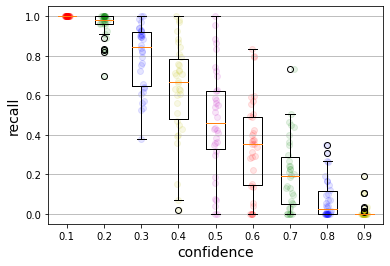

In [1762]:
labels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
plt.boxplot(vals_filter, labels=labels)

palette = ['r', 'g', 'b', 'y', 'm', 'r', 'g', 'b', 'y', 'm']
for x, val, c in zip(xs, vals, palette):
    plt.scatter(x, val, alpha=0.1, color=c)
plt.grid(True, axis='y')
plt.xlabel('confidence', fontsize=14)
plt.ylabel('recall', fontsize=14)
# plt.savefig('boxscatterplot.pdf')
plt.show()

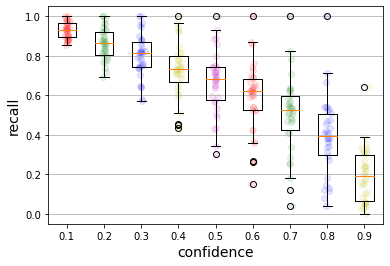

In [1763]:
labels = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
plt.boxplot(vals_filter_, labels=labels)

palette = ['r', 'g', 'b', 'y', 'm', 'r', 'g', 'b', 'y', 'm']
for x, val, c in zip(xs_, vals_, palette):
    plt.scatter(x, val, alpha=0.1, color=c)
    
plt.grid(True, axis='y')
plt.xlabel('confidence', fontsize=14)
plt.ylabel('recall', fontsize=14)
# plt.savefig('boxscatterplot.pdf')
plt.show()

In [ ]:
def draw_plot(ax, data, xs, offset, edge_color, fill_color, label):
    pos = np.arange(9) + offset
    flierprops = dict(
        marker='o', markerfacecolor=fill_color, markersize=3,
        linestyle='none', markeredgecolor=edge_color
    )
    bp = ax.boxplot(
        data, positions=pos, widths=0.3, patch_artist=True,
        flierprops=flierprops, manage_ticks=False
    )
    for element in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
        plt.setp(bp[element], color=edge_color)
    for patch in bp['boxes']:
        patch.set(facecolor=fill_color)
    return bp

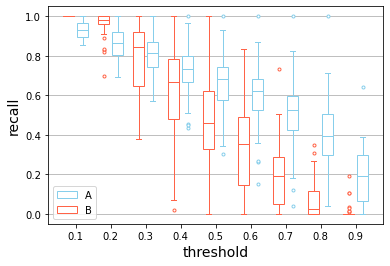

In [ ]:
fig, ax = plt.subplots()

bp1 = draw_plot(ax, vals_filter_, xs_, +0.2, "skyblue", "white", "A")
bp2 = draw_plot(ax, vals_filter,  xs,  -0.2, "tomato", "white", "B")

ax.legend([bp1["boxes"][0], bp2["boxes"][0]], ['A', 'B'], loc='lower left')

plt.xticks(range(9), labels)
plt.grid(True, axis='y')
plt.xlabel('threshold', fontsize=14)
plt.ylabel('recall', fontsize=14)
plt.savefig('boxplot1.pdf')
plt.show()

In [ ]:
#https://stackoverflow.com/questions/43612687/python-matplotlib-box-plot-two-data-sets-side-by-side